[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/bniko05/sentiment-and-image-classification/blob/main/notebooks/03_fashionmnist_resnet18.ipynb)

# Fashion-MNIST Image Classification: Fine-tuned ResNet-18 (PyTorch)

A pre-trained **ResNet-18** encoder with a custom MLP head, fine-tuned on Fashion-MNIST with data augmentation and early stopping.

> ⚡ In Colab, select **Runtime → Change runtime type → T4 GPU** before running.

In [ ]:
from __future__ import annotations

import copy
import os
import random
from dataclasses import dataclass
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split

import matplotlib.pyplot as plt

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support

from torchvision import datasets, transforms
from torchvision import models as tv_models

In [ ]:
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
print(device)

cuda


In [ ]:
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)

MNIST_MEAN_1CH = (0.1307,)
MNIST_STD_1CH = (0.3081,)

def _norm_stats(channels: int, scheme: str) -> Tuple[Tuple[float, ...], Tuple[float, ...]]:
    if scheme == "mnist":
        if channels == 1:
            return MNIST_MEAN_1CH, MNIST_STD_1CH
        # replicate MNIST stats to 3 channels
        return (MNIST_MEAN_1CH[0],) * channels, (MNIST_STD_1CH[0],) * channels

    if scheme == "imagenet":
        if channels != 3:
            raise ValueError("ImageNet normalization expects 3 channels")
        return IMAGENET_MEAN, IMAGENET_STD

    raise ValueError(f"Unknown normalization scheme: {scheme}")


In [ ]:
def make_fashionmnist_loaders(
    root: str = "./data",
    batch_size: int = 128,
    val_ratio: float = 0.2,
    img_size: int = 224,
    channels: int = 3,
    normalize: str = "imagenet",
    augment: bool = True,
    num_workers: int = 2,
    pin_memory: bool = True,
) -> Tuple[DataLoader, DataLoader, DataLoader]:
    """Create (train, val, test) loaders for MNIST with a reproducible train/val split."""

    mean, std = _norm_stats(channels=channels, scheme=normalize)

    train_tfms: List[object] = []

    # MNIST images are grayscale PIL images.
    if channels == 3:
        train_tfms.append(transforms.Grayscale(num_output_channels=3))

    if img_size != 28:
        train_tfms.append(transforms.Resize((img_size, img_size)))

    if augment:
        # 1-2 simple, commonly-used augmentations for MNIST
        train_tfms.extend(
            [
                transforms.RandomRotation(degrees=10),
                transforms.RandomHorizontalFlip(),
            ]
        )

    train_tfms.extend(
        [
            transforms.ToTensor(),
            transforms.Normalize(mean=mean, std=std),
        ]
    )

    test_tfms: List[object] = []

    if channels == 3:
        test_tfms.append(transforms.Grayscale(num_output_channels=3))

    if img_size != 28:
        test_tfms.append(transforms.Resize((img_size, img_size)))

    test_tfms.extend(
        [
            transforms.ToTensor(),
            transforms.Normalize(mean=mean, std=std),
        ]
    )

    train_transform = transforms.Compose(train_tfms)
    test_transform = transforms.Compose(test_tfms)

    train_full = datasets.FashionMNIST(root=root, train=True, download=True, transform=train_transform)
    test_set = datasets.FashionMNIST(root=root, train=False, download=True, transform=test_transform)

    val_len = int(len(train_full) * val_ratio)
    train_len = len(train_full) - val_len

    # deterministic split
    g = torch.Generator().manual_seed(42)
    train_set, val_set = random_split(train_full, [train_len, val_len], generator=g)

    train_loader = DataLoader(
        train_set,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=pin_memory,
    )
    val_loader = DataLoader(
        val_set,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=pin_memory,
    )
    test_loader = DataLoader(
        test_set,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=pin_memory,
    )

    print(
        f"FASHIONMNIST loaders | train={len(train_set)} val={len(val_set)} test={len(test_set)} | "
        f"img_size={img_size} channels={channels} augment={augment} normalize={normalize}"
    )

    return train_loader, val_loader, test_loader

In [ ]:
def make_resnet18(
    num_classes: int = 10,
    pretrained: bool = False,
    freeze_backbone: bool = False,
) -> nn.Module:

    weights = None
    if pretrained:
        # torchvision will download weights if needed; if offline, we fall back.
        try:
            weights = tv_models.ResNet18_Weights.DEFAULT
        except Exception:
            weights = None

    try:
        model = tv_models.resnet18(weights=weights)
    except Exception as e:
        print(f"[WARN] Could not load pretrained weights ({e}). Falling back to random init.")
        model = tv_models.resnet18(weights=None)

    in_features = model.fc.in_features

    hidden_units = 256
    dropout_rate = 0.5

    model.fc = nn.Sequential(
        nn.Linear(in_features, hidden_units),
        nn.ReLU(),
        nn.Dropout(p=dropout_rate),
        nn.Linear(hidden_units, num_classes)
    )

    if freeze_backbone:
        for name, p in model.named_parameters():
            if not name.startswith("fc"):
                p.requires_grad = False

    return model

In [ ]:
@dataclass
class RunConfig:
    epochs: int = 10
    lr: float = 1e-4
    weight_decay: float = 1e-4
    amp: bool = True
    max_batches_per_epoch: Optional[int] = None  # set for quick dev runs


def _iter_limited(loader: DataLoader, max_batches: Optional[int]):
    if max_batches is None:
        yield from loader
    else:
        for i, batch in enumerate(loader):
            if i >= max_batches:
                break
            yield batch


def train_model(
    model: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    criterion: nn.Module,
    optimizer: optim.Optimizer,
    cfg: RunConfig,
    patience: int = 3
) -> Tuple[List[float], List[float], List[float]]:


    train_losses: List[float] = []
    val_losses: List[float] = []
    val_accuracies: List[float] = []

    best_model = copy.deepcopy(model.state_dict())
    best_accuracy = 0.0
    best_epoch = 0
    patience_counter = 0

    for epoch in range(cfg.epochs):
        # --- train ---
        model.train()
        running = 0.0
        nb = 0

        for images, labels in _iter_limited(train_loader, cfg.max_batches_per_epoch):
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            logits = model(images)
            loss = criterion(logits, labels)


            loss.backward()
            optimizer.step()

            running += float(loss.detach().cpu().item())
            nb += 1

        train_loss = running / max(nb, 1)
        train_losses.append(train_loss)

        # --- val ---
        model.eval()
        val_loss = 0.0
        total = 0
        correct = 0
        running = 0.0
        nb = 0

        with torch.no_grad():
            for images, labels in _iter_limited(val_loader, cfg.max_batches_per_epoch):
                images = images.to(device)
                labels = labels.to(device)

                logits = model(images)

                loss = criterion(logits, labels)
                running += float(loss.detach().cpu())
                nb += 1

                _, predicted = torch.max(logits, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        val_loss = running / max(nb, 1)
        epoch_accuracy = 100 * correct / total

        val_accuracies.append(epoch_accuracy)
        val_losses.append(val_loss)

        print(
            f"Epoch {epoch+1}/{cfg.epochs} | "
            f"train_loss={train_loss:.4f} val_loss={val_loss:.4f}"
        )
        if epoch_accuracy > best_accuracy:
            best_accuracy = epoch_accuracy
            best_epoch = epoch + 1
            best_model = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch+1}.")
            break

    model.load_state_dict(best_model)
    return train_losses, val_losses, val_accuracies


def evaluate_model(model: nn.Module, loader: DataLoader):
    model.eval()

    y_true: List[int] = []
    y_pred: List[int] = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            logits = model(images)
            preds = logits.argmax(dim=1).detach().cpu().numpy().tolist()

            y_pred.extend(preds)
            y_true.extend(labels.numpy().tolist())

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat','Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

    acc = accuracy_score(y_true, y_pred)

    #Υπολογισμός του recall, precision και f1 για κάθε κλάση
    precision_per_class, recall_per_class, f1_per_class, _ = precision_recall_fscore_support(y_true, y_pred, average=None, zero_division=0)

    #Υπολογισμός των micro-averaged
    precision_micro, recall_micro, f1_micro, _ = precision_recall_fscore_support(y_true, y_pred, average='micro', zero_division=0)

    #Υπολογισμός των macro-averaged
    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(y_true, y_pred, average='macro', zero_division=0)

    metrics_per_class = {}
    for(i, class_name) in enumerate(class_names):
        metrics_per_class[class_name] = {
            'precision': precision_per_class[i],
            'recall': recall_per_class[i],
            'f1': f1_per_class[i]}

    average_metrics = {
        'accuracy': acc,
        'precision_macro': precision_macro,
        'recall_macro': recall_macro,
        'f1_macro': f1_macro,
        'precision_micro': precision_micro,
        'recall_micro': recall_micro,
        'f1_micro': f1_micro}

    return metrics_per_class, average_metrics

In [ ]:
def plot_loss_curves(train_losses, val_losses, val_accuracies):

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    ax1, ax2 = axes


    # Καμπύλες loss
    ax1.plot(train_losses, label='Train Loss', marker='o', linewidth=2)
    ax1.plot(val_losses, label='Validation Loss', marker='s', linewidth=2)
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.set_title('Train/Validation Loss Curves')
    ax1.legend()
    ax1.grid(True, alpha=0.3)


    # Καμπύλη accuracy
    ax2.plot(val_accuracies, label='Validation Accuracy', marker='^', color='green', linewidth=2)
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.set_title('Validation Accuracy Curve')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

In [ ]:
def print_metrics_tables(results_per_class, summary_metrics):

    # Πίνακας με τις μετρικές για κάθε κλάση
    print("\n" + "="*60)
    print("Αποτελέσματα Για Κάθε Κλάση")
    print("="*60)
    print(f"{'Κλάση':<15} {'Precision':<12} {'Recall':<12} {'F1-Score':<12}")
    print("-"*60)

    for class_name, metrics in results_per_class.items():
        print(f"{class_name:<15} {metrics['precision']:<12.4f} {metrics['recall']:<12.4f} "
              f"{metrics['f1']:<12.4f}")

    print("-"*60)

    print("\n" + "="*60)
    print("Κύριες Μετρικές")
    print("="*60)
    print(f"{'Μέτρηση':<20} {'Τιμή':<12}")
    print("-"*60)
    print(f"{'Accuracy':<20} {summary_metrics['accuracy']:<12.4f}")
    print(f"{'Macro Precision':<20} {summary_metrics['precision_macro']:<12.4f}")
    print(f"{'Macro Recall':<20} {summary_metrics['recall_macro']:<12.4f}")
    print(f"{'Macro F1':<20} {summary_metrics['f1_macro']:<12.4f}")
    print(f"{'Micro Precision':<20} {summary_metrics['precision_micro']:<12.4f}")
    print(f"{'Micro Recall':<20} {summary_metrics['recall_micro']:<12.4f}")
    print(f"{'Micro F1':<20} {summary_metrics['f1_micro']:<12.4f}")
    print("-"*60)

In [ ]:
def main():
    train_loader, val_loader, test_loader = make_fashionmnist_loaders(
        root="./data",
        batch_size=64,
        val_ratio=0.2,
        img_size=224,
        channels=3,
        normalize="imagenet",
        augment=True,
        num_workers=2
    )

    model = make_resnet18(
        num_classes=10,
        pretrained=True,
        freeze_backbone=False
    )

    model = model.to(device)

    cfg = RunConfig(
        epochs=10,
        lr=1e-4,
        weight_decay=1e-4,
        amp=False,
        max_batches_per_epoch=None)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)

    # Εκπαίδευση μοντέλου
    train_losses, val_losses, val_accuracies = train_model(model, train_loader, val_loader, criterion, optimizer, cfg)

    # Γραφήματα
    plot_loss_curves(train_losses, val_losses, val_accuracies)

    # Αξιολόγηση
    test_results_per_class, summary_results = evaluate_model(model, test_loader)

    print(f"\nΒασικές μετρικές test set:")
    print(f"  Accuracy: {summary_results['accuracy']:.4f}")
    print(f"  Precision (macro): {summary_results['precision_macro']:.4f}")
    print(f"  Recall (macro): {summary_results['recall_macro']:.4f}")
    print(f"  F1 (macro): {summary_results['f1_macro']:.4f}")

    # Εκτύπωση πινάκων
    print_metrics_tables(test_results_per_class, summary_results)

100%|██████████| 26.4M/26.4M [00:02<00:00, 10.6MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 185kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.47MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 4.16MB/s]


FASHIONMNIST loaders | train=48000 val=12000 test=10000 | img_size=224 channels=3 augment=True normalize=imagenet
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 205MB/s]


Epoch 1/10 | train_loss=0.3821 val_loss=0.2113
Epoch 2/10 | train_loss=0.2135 val_loss=0.1989
Epoch 3/10 | train_loss=0.1782 val_loss=0.1878
Epoch 4/10 | train_loss=0.1550 val_loss=0.1856
Epoch 5/10 | train_loss=0.1407 val_loss=0.1727
Epoch 6/10 | train_loss=0.1270 val_loss=0.1651
Epoch 7/10 | train_loss=0.1116 val_loss=0.1740
Epoch 8/10 | train_loss=0.1004 val_loss=0.1668
Epoch 9/10 | train_loss=0.0926 val_loss=0.1903
Epoch 10/10 | train_loss=0.0821 val_loss=0.1825


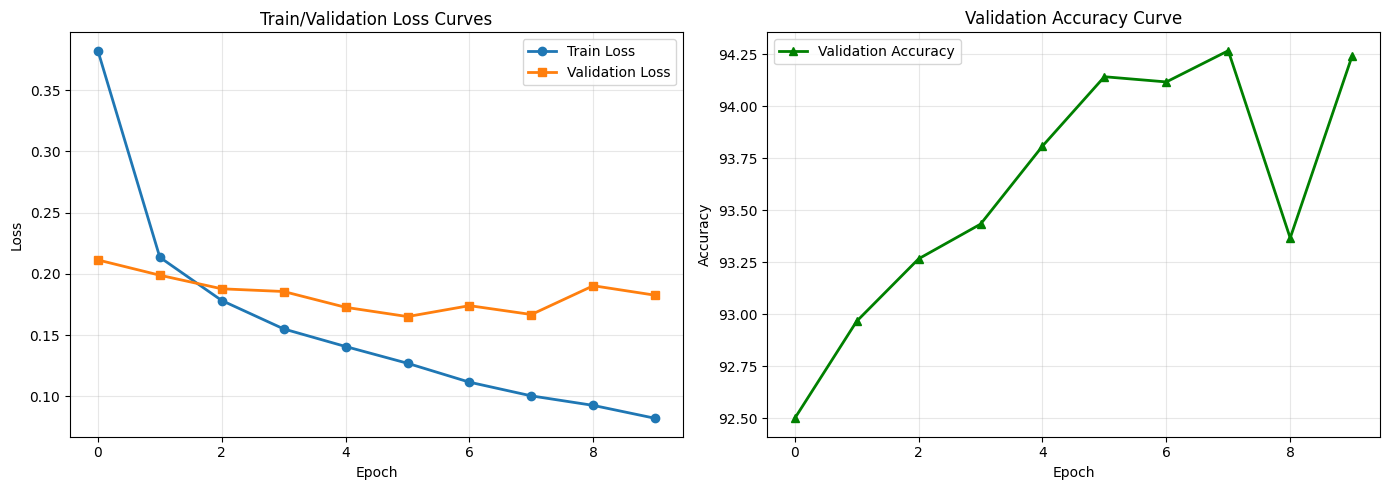


Βασικές μετρικές test set:
  Accuracy: 0.9430
  Precision (macro): 0.9429
  Recall (macro): 0.9430
  F1 (macro): 0.9428

Αποτελέσματα Για Κάθε Κλάση
Κλάση           Precision    Recall       F1-Score    
------------------------------------------------------------
T-shirt/top     0.8925       0.8970       0.8948      
Trouser         0.9970       0.9880       0.9925      
Pullover        0.9285       0.9090       0.9186      
Dress           0.9199       0.9650       0.9419      
Coat            0.9263       0.9180       0.9221      
Sandal          0.9804       0.9980       0.9891      
Shirt           0.8374       0.8190       0.8281      
Sneaker         0.9797       0.9640       0.9718      
Bag             0.9910       0.9960       0.9935      
Ankle boot      0.9760       0.9760       0.9760      
------------------------------------------------------------

Κύριες Μετρικές
Μέτρηση              Τιμή        
------------------------------------------------------------
Accuracy   

In [ ]:
main()